# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv("cleaned_aviation_data.csv")

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
# Split the airplane groups; smaller and larger aircraft
df["Aircraft.Size"] = np.where(df["Total.Passengers"] < 20, "Small", "Large")
small = df[df["Aircraft.Size"] == "Small"]
large = df[df["Aircraft.Size"] == "Large"]

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

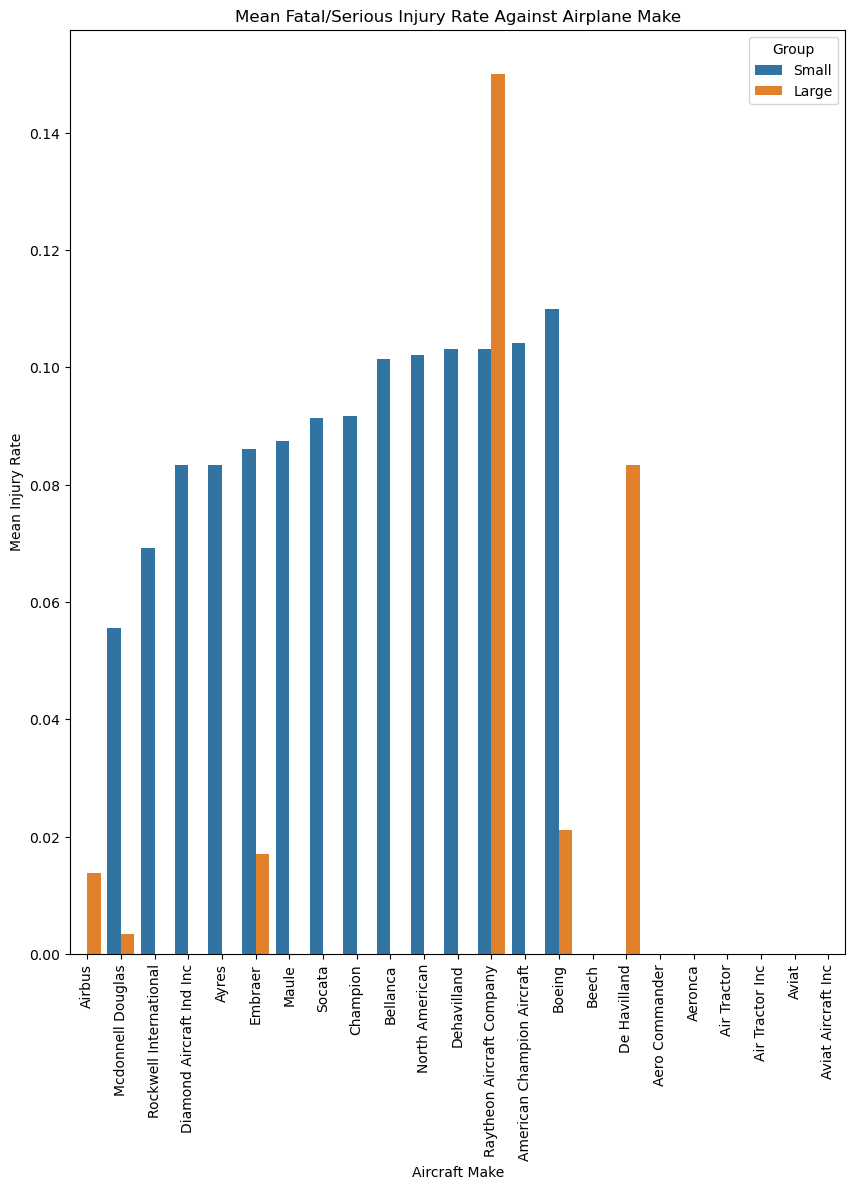

In [4]:
# exploring human injury risk per make in large and small aircraft
small_makes = df[df["Aircraft.Size"] == "Small"].groupby("Make").agg(
    mean_risk = ("Serious.Injury.Rate", "mean"), 
    count = ("Make", "count"))
large_makes = df[df["Aircraft.Size"] == "Large"].groupby("Make").agg(
    mean_risk = ("Serious.Injury.Rate", "mean"),
    count = ("Make", "count"))

# choosing the 15 makes for each group with lowest fatal/serious injury
small_makes_15 = small_makes.sort_values("mean_risk").head(15)
large_makes_15 = large_makes.sort_values("mean_risk").head(15)

# Plot them side by side
small_makes_15["Group"] = "Small"
large_makes_15["Group"] = "Large"
small_makes_15 = small_makes_15.reset_index()
large_makes_15 = large_makes_15.reset_index()

plot_1 = pd.concat([small_makes_15, large_makes_15])
plt.figure(figsize =(10,12))

sns.barplot(data=pd.concat([small_makes_15.assign(Group="Small"), 
                large_makes_15.assign(Group = "Large")
                ], ignore_index=True), x="Make", y="mean_risk", hue="Group")
plt.xticks(rotation=90)
plt.title("Mean Fatal/Serious Injury Rate Against Airplane Make")
plt.ylabel("Mean Injury Rate")
plt.xlabel("Aircraft Make")
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

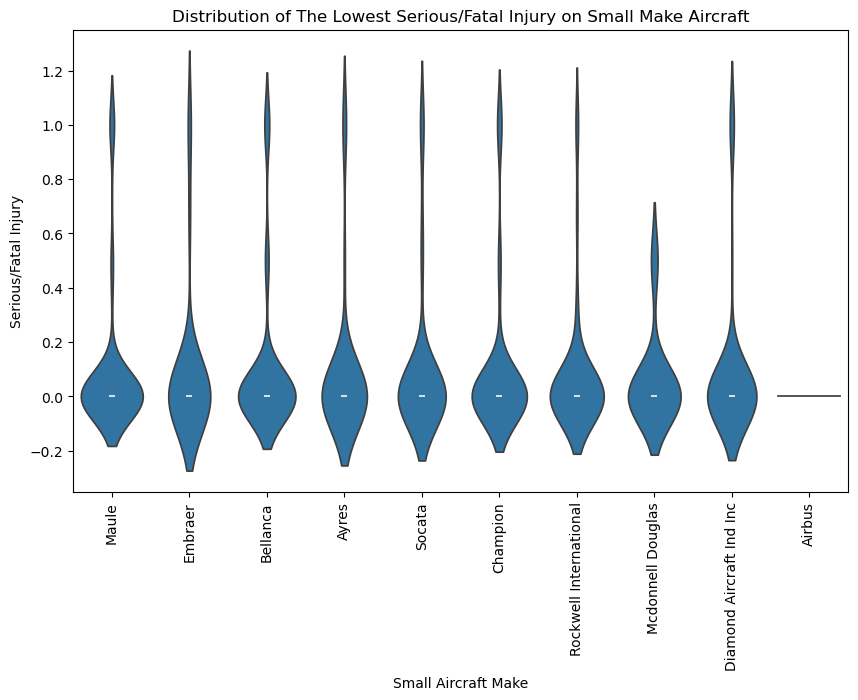

In [5]:
small_makes = df[df["Aircraft.Size"] == "Small"].groupby("Make").agg(
    mean_risk = ("Serious.Injury.Rate", "mean"), 
    count = ("Make", "count"))
small_makes_low10 = small_makes.sort_values("mean_risk").head(10).index
small_make_df = df[(df["Aircraft.Size"] == "Small") & (df["Make"].isin(small_makes_low10))]

# create the plot
plt.figure(figsize=(10,6))
sns.violinplot(data =small_make_df, x="Make", y="Serious.Injury.Rate")
plt.xticks(rotation=90)
plt.title("Distribution of The Lowest Serious/Fatal Injury on Small Make Aircraft")
plt.ylabel("Serious/Fatal Injury")
plt.xlabel("Small Aircraft Make")
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

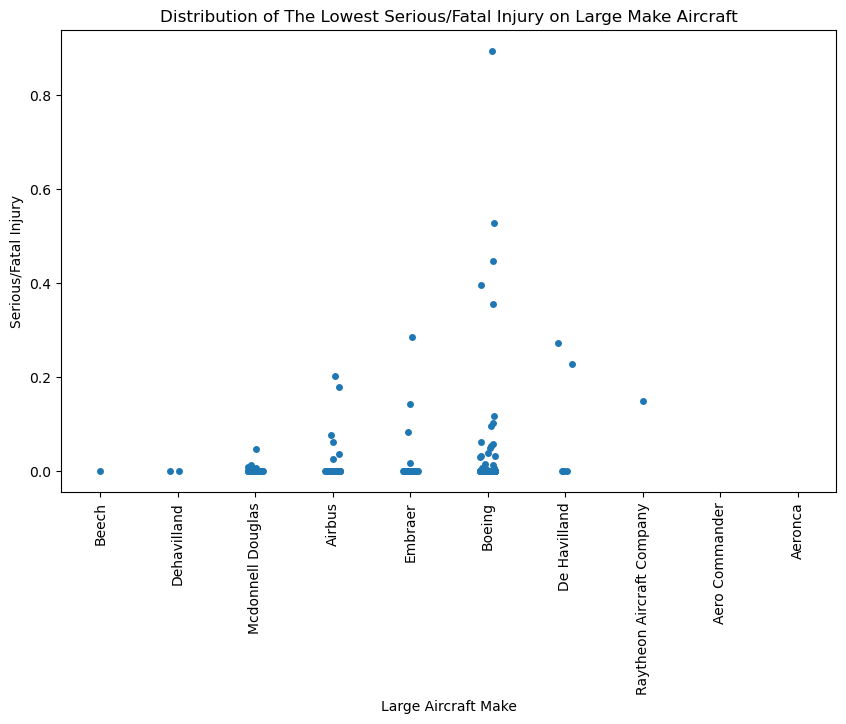

In [6]:
large_makes = df[df["Aircraft.Size"] == "Large"].groupby("Make").agg(
    mean_risk = ("Serious.Injury.Rate", "mean"), 
    count = ("Make", "count"))
large_makes_low10 = large_makes.sort_values("mean_risk").head(10).index
large_make_df = df[(df["Aircraft.Size"] == "Large") & (df["Make"].isin(large_makes_low10))]

# create the plot
plt.figure(figsize=(10,6))
sns.stripplot(data = large_make_df, x="Make", y="Serious.Injury.Rate", order=large_makes_low10)
plt.xticks(rotation=90)
plt.title("Distribution of The Lowest Serious/Fatal Injury on Large Make Aircraft")
plt.ylabel("Serious/Fatal Injury")
plt.xlabel("Large Aircraft Make")
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [ ]:
# rate of aircraft destruction would be;
# check unique columns in Aircraft Damage to identify which value to use
df["Aircraft.damage"].unique()
# Create a column with binary values 1 for destroyed, and 0 otherwise
df["Destroyed_Craft"] = (df["Aircraft.damage"] == "Destroyed").astype(int)

# For small aircraft
small_destroyed = (df[df["Aircraft.Size"] == "Small"].groupby("Make")["Destroyed_Craft"].mean().sort_values().head(15))
large_destroyed = (df[df["Aircraft.Size"] == "Large"].groupby("Make")["Destroyed_Craft"].mean().sort_values().head(15))



Make
Taylorcraft                       0.0
Grumman Acft Eng Cor-Schweizer    0.0
Ercoupe                           0.0
Diamond Aircraft Ind Inc          0.0
Dehavilland                       0.0
Stinson                           0.0
North American                    0.0
Champion                          0.0
Luscombe                          0.0
Maule                             0.0
Ayres                             0.0
Aviat Aircraft Inc                0.0
Socata                            0.0
American Champion Aircraft        0.0
Air Tractor                       0.0
Name: Destroyed_Craft, dtype: float64

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Observations

* For both small and large aircraft, the lower-risk makes exhibit lower destruction rates and low serious/fatal injury fractions. For example Dehavilland and Grumman Acft Eng Cor Schweizer showed lower rates of destruction and the distribution of injuries was clustered on the low end. 
* In contrast, more common manufacturers like Cessna displayed higher destruction rates. This suggests that even among better performing aircraft makes, there is still a high risk of injury. 
* The overall distribution appeared right skewed, with a few makes contributing disproportionately to higher risk outcomes. 

### Recommendations
* The makes recommended based on their consistently lower destruction rates and lower variability in injuries are Grumman Acft Eng Cor-Schweizer and Luscombe. 
* On the other hand, makes like the Cessna have shown higher injury fractions and a bit more variability in the injuries passengers sustain. This is a make that should be approached with caution when focusing on the safeety of aircraft. 

In conclusion, aircraft safety has varied between manufacturers, and caution should be exercised when choosing makes based on safety. Based on the skewness of the plots, selecting manufacturers with consistently lower destruction and injury rates is ideal. 

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

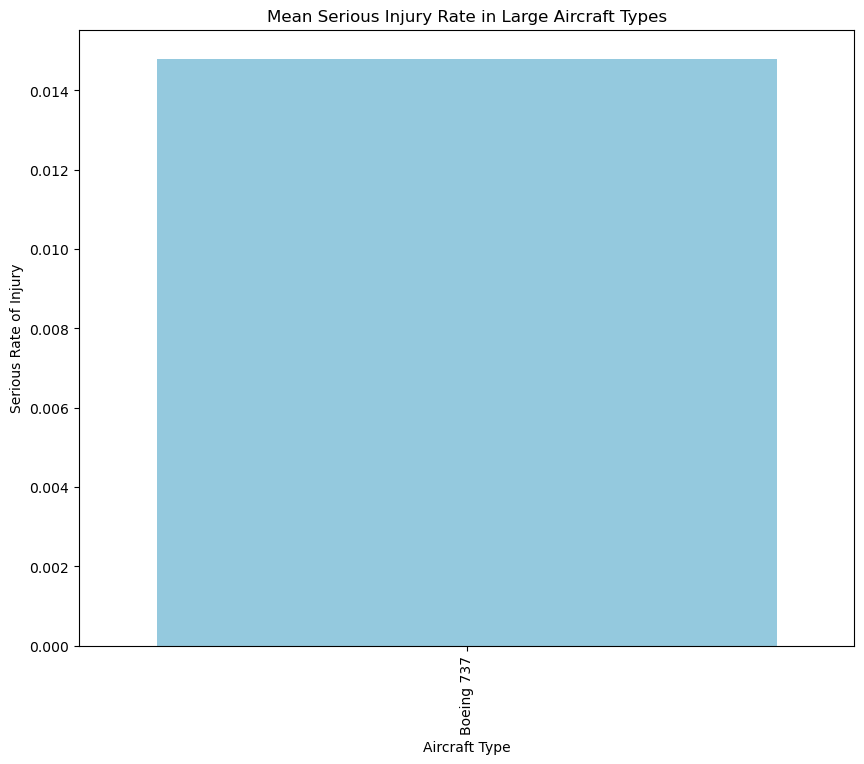

In [36]:
# mean serious injury rate 
large_models = (large.groupby("Aircraft.Type").agg(mean_risk=("Serious.Injury.Rate", "mean"),
                                                   count =("Aircraft.Type", "count")))

# filter to at least 10 individual examples
large_models = large_models[large_models["count"] >= 10]
large_models = large_models.sort_values("mean_risk").reset_index()

# bar plot
plt.figure(figsize=(10,8))
sns.barplot(data=large_models, x = "Aircraft.Type", y = "mean_risk", color="skyblue")
plt.xticks(rotation=90)
plt.title("Mean Serious Injury Rate in Large Aircraft Types")
plt.ylabel("Serious Rate of Injury")
plt.xlabel("Aircraft Type")
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

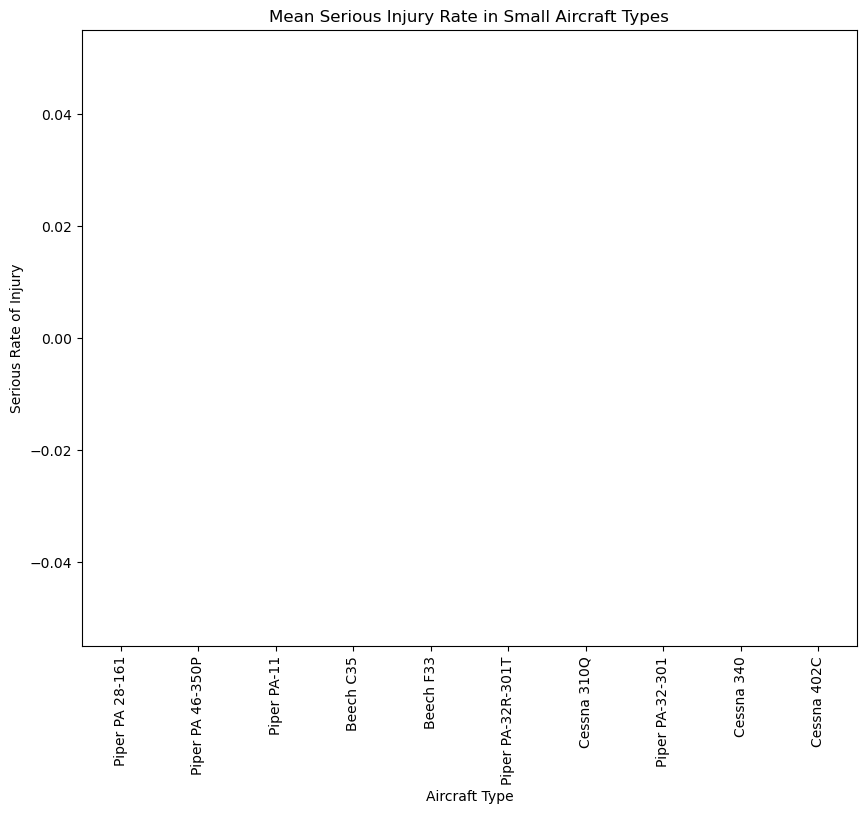

In [37]:
#mean serious rate of injury for small aircraft
small_models = (small.groupby("Aircraft.Type").agg(mean_risk=("Serious.Injury.Rate", "mean"), count=("Aircraft.Type", "count")))

# filter to at least 10 examples, and limit it to the lowest
small_models = small_models[small_models["count"] >=10]
small_models = small_models.sort_values("mean_risk").reset_index()
small_models_10 = small_models.head(10)

# bar plot
plt.figure(figsize=(10,8))
sns.barplot(data=small_models_10, x = "Aircraft.Type", y = "mean_risk", color="blue")
plt.xticks(rotation=90)
plt.title("Mean Serious Injury Rate in Small Aircraft Types")
plt.ylabel("Serious Rate of Injury")
plt.xlabel("Aircraft Type")
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Observations
* The large aircraft barplot only shows one value, the Boeing 737. This indicates that the large aircraft accident data is sparse in the dataset, and only this model was retained. 
* The barplot created for smal aircraft data showed that the 10 aircraft with the lowest risk had a mean serious rate of injury of 0. This would suggest that in the recorded accidents in these aircraft, passengers were not seriously or fatally injured. 

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [ ]:
# Option 1- Weather Condition
weather_cond = (df.groupby("Weather.Condition")["Serious.Injury.Rate"].agg(["mean", "count"]).sort_values("mean"))
weather_cond

,mean,count
Weather.Condition,,
IMC,0.072273,755
VMC,0.120341,12717


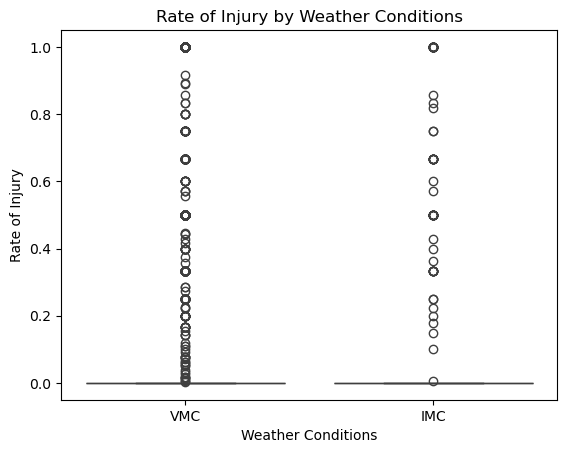

In [41]:
# Create a plot for visualization
sns.boxplot(data=df, x="Weather.Condition", y="Serious.Injury.Rate")
plt.title("Rate of Injury by Weather Conditions")
plt.xlabel("Weather Conditions")
plt.ylabel("Rate of Injury")
plt.show()